<a href="https://colab.research.google.com/github/kamilal-hub/DSA210-TERM-PROJECT/blob/main/dsa210.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
!wget https://datasets.imdbws.com/title.basics.tsv.gz
!wget https://datasets.imdbws.com/title.ratings.tsv.gz

--2026-04-11 21:03:03--  https://datasets.imdbws.com/title.basics.tsv.gz
Resolving datasets.imdbws.com (datasets.imdbws.com)... 13.35.202.104, 13.35.202.21, 13.35.202.61, ...
Connecting to datasets.imdbws.com (datasets.imdbws.com)|13.35.202.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 220081410 (210M) [binary/octet-stream]
Saving to: ‘title.basics.tsv.gz.6’

title.basics.tsv.gz 100%[===================>] 209.89M   160MB/s    in 1.3s    

2026-04-11 21:03:04 (160 MB/s) - ‘title.basics.tsv.gz.6’ saved [220081410/220081410]

--2026-04-11 21:03:04--  https://datasets.imdbws.com/title.ratings.tsv.gz
Resolving datasets.imdbws.com (datasets.imdbws.com)... 13.35.202.104, 13.35.202.21, 13.35.202.61, ...
Connecting to datasets.imdbws.com (datasets.imdbws.com)|13.35.202.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8377879 (8.0M) [binary/octet-stream]
Saving to: ‘title.ratings.tsv.gz.6’

title.ratings.tsv.g 100%[===================>

In [50]:
import pandas as pd

# 1. Dosyaları oku (Pandas sıkıştırılmış dosyayı otomatik açar)
basics = pd.read_csv('title.basics.tsv.gz', sep='\t', low_memory=False, na_values='\\N')
ratings = pd.read_csv('title.ratings.tsv.gz', sep='\t', low_memory=False, na_values='\\N')

# 2. Sadece TV dizilerini seç (Proposal'ındaki odak noktan)
tv_series = basics[basics['titleType'] == 'tvSeries']

# 3. İsim ve puan tablolarını birleştir
merged = pd.merge(tv_series, ratings, on='tconst')

# 4. Yılları sayıya çevir ve 2010-2025 arasını filtrele [cite: 13]
merged['startYear'] = pd.to_numeric(merged['startYear'], errors='coerce')
final_list = merged[(merged['startYear'] >= 2010) & (merged['startYear'] <= 2025)]

# 5. En popüler (en çok oy alan) 250 diziyi seç
top_250 = final_list.sort_values(by='numVotes', ascending=False).head(250)

# Sonucu kontrol et
print(f"Toplam {len(top_250)} dizi başarıyla filtrelendi.")
top_250[['primaryTitle', 'averageRating', 'numVotes', 'startYear']].head(10)

Toplam 250 dizi başarıyla filtrelendi.


,primaryTitle,averageRating,numVotes,startYear
26409,Game of Thrones,9.2,2602061,2011.0
90669,Stranger Things,8.6,1688448,2016.0
48172,The Walking Dead,8.1,1191513,2010.0
46558,Sherlock,9.0,1085326,2010.0
35384,The Boys,8.6,847308,2019.0
74520,Better Call Saul,9.0,827010,2015.0
65973,Peaky Blinders,8.7,769379,2013.0
31327,Squid Game,7.9,755539,2021.0
64628,True Detective,8.8,751369,2014.0
59121,Black Mirror,8.7,734585,2011.0


In [51]:
import pandas as pd
from pytrends.request import TrendReq
import time
import random

pytrends = TrendReq(hl='en-US', tz=360)

# İlk 50 diziyi hedefleyelim (250 dizi için bu döngü uzun sürebilir, parça parça yapmak güvenli)
series_list = top_250['primaryTitle'].head(50).tolist()
all_trends = []

print("Veri çekme işlemi başlıyor... (Bu işlem biraz zaman alacaktır)")

# Google Trends 5 kelimeye kadar izin verir ama temiz veri için tek tek veya
# küçük gruplar daha sağlıklıdır. Biz tek tek ama güvenli gidelim:
for name in series_list:
    try:
        print(f"Sıradaki dizi: {name}")
        pytrends.build_payload([name], timeframe='2010-01-01 2025-12-31')
        df = pytrends.interest_over_time()

        if not df.empty:
            # Sadece o dizinin arama hacmini alalım
            series_trend = df[name].reset_index()
            series_trend['title'] = name
            all_trends.append(series_trend)
            print(f"--- {name} başarıyla çekildi.")

        # Google'ı kızdırmamak için 7-12 saniye arası rastgele bekleme
        wait_time = random.uniform(7, 12)
        time.sleep(wait_time)

    except Exception as e:
        print(f"!!! {name} çekilirken hata: {e}")
        print("60 saniye dinlenmeye geçiliyor...")
        time.sleep(60) # Engel yediğimizde uzun mola
        continue

# Tüm verileri tek bir tabloda birleştir
if all_trends:
    final_trends_df = pd.concat(all_trends, ignore_index=True)
    print("İşlem tamamlandı!")
else:
    print("Hiç veri çekilemedi.")

Veri çekme işlemi başlıyor... (Bu işlem biraz zaman alacaktır)
Sıradaki dizi: Game of Thrones
!!! Game of Thrones çekilirken hata: The request failed: Google returned a response with code 429
60 saniye dinlenmeye geçiliyor...
Sıradaki dizi: Stranger Things
--- Stranger Things başarıyla çekildi.
Sıradaki dizi: The Walking Dead
--- The Walking Dead başarıyla çekildi.
Sıradaki dizi: Sherlock
--- Sherlock başarıyla çekildi.
Sıradaki dizi: The Boys
--- The Boys başarıyla çekildi.
Sıradaki dizi: Better Call Saul
--- Better Call Saul başarıyla çekildi.
Sıradaki dizi: Peaky Blinders
--- Peaky Blinders başarıyla çekildi.
Sıradaki dizi: Squid Game
--- Squid Game başarıyla çekildi.
Sıradaki dizi: True Detective
--- True Detective başarıyla çekildi.
Sıradaki dizi: Black Mirror
--- Black Mirror başarıyla çekildi.
Sıradaki dizi: The Last of Us
--- The Last of Us başarıyla çekildi.
Sıradaki dizi: Attack on Titan
--- Attack on Titan başarıyla çekildi.
Sıradaki dizi: Rick and Morty
--- Rick and Morty b

In [52]:
final_trends_df.to_csv('tv_series_google_trends.csv', index=False)
print("Veri başarıyla kaydedildi!")

Veri başarıyla kaydedildi!


In [53]:
# 1. Her dizinin ulaştığı en yüksek arama puanını (Peak Interest) bulalım
peak_interests = []
for title in final_trends_df['title'].unique():
    # Dizinin kendi sütunundaki maksimum değeri alıyoruz
    peak_val = final_trends_df[final_trends_df['title'] == title][title].max()
    peak_interests.append({'primaryTitle': title, 'peak_search': peak_val})

summary_trends = pd.DataFrame(peak_interests)

# 2. IMDb (top_250) verisi ile Trends özetini birleştiriyoruz
# 'primaryTitle' sütunu üzerinden iki tabloyu eşleştiriyoruz [cite: 18]
combined_df = pd.merge(top_250, summary_trends, on='primaryTitle')

print(f"{len(combined_df)} dizi için tüm veriler başarıyla birleştirildi.")
combined_df[['primaryTitle', 'averageRating', 'peak_search']].head()

49 dizi için tüm veriler başarıyla birleştirildi.


,primaryTitle,averageRating,peak_search
0,Stranger Things,8.6,100.0
1,The Walking Dead,8.1,100.0
2,Sherlock,9.0,100.0
3,The Boys,8.6,100.0
4,Better Call Saul,9.0,100.0


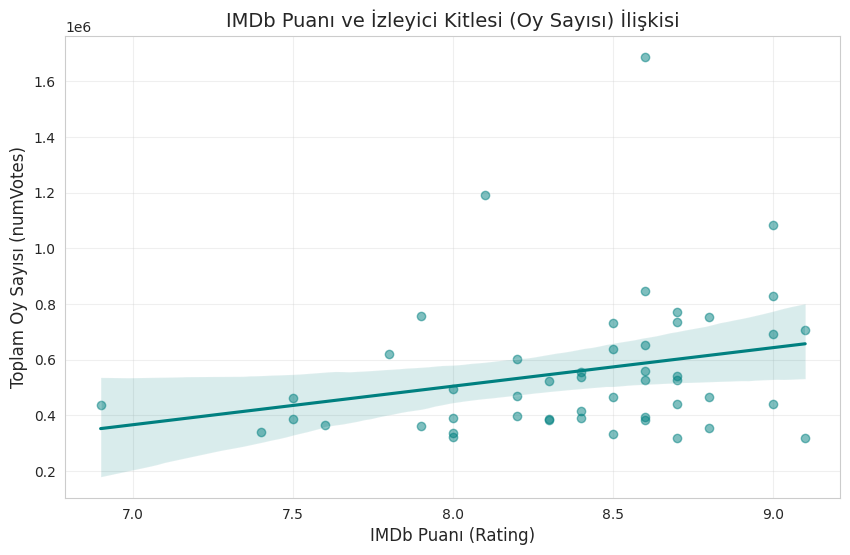

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# IMDb Puanı ile Toplam Oy Sayısı arasındaki ilişki
sns.regplot(data=combined_df, x='averageRating', y='numVotes', color='teal', scatter_kws={'alpha':0.5})
plt.title('IMDb Puanı ve İzleyici Kitlesi (Oy Sayısı) İlişkisi', fontsize=14)
plt.xlabel('IMDb Puanı (Rating)', fontsize=12)
plt.ylabel('Toplam Oy Sayısı (numVotes)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [55]:
# Hipotez: Yüksek puanlı diziler daha geniş kitlelere (daha çok oya) mi ulaşıyor?
correlation = combined_df['averageRating'].corr(combined_df['numVotes'])

print("-" * 45)
print("HİPOTEZ TESTİ SONUCU (14 NİSAN TESLİMATI)")
print(f"Puan ve Oy Sayısı Arasındaki Korelasyon: {correlation:.2f}")
print("-" * 45)

if correlation > 0.4:
    print("Yorum: Pozitif bir ilişki var. Kaliteli diziler genelde daha çok popülerleşiyor.")
else:
    print("Yorum: İlişki zayıf. Yüksek puan her zaman popülerlik getirmiyor.")

---------------------------------------------
HİPOTEZ TESTİ SONUCU (14 NİSAN TESLİMATI)
Puan ve Oy Sayısı Arasındaki Korelasyon: 0.26
---------------------------------------------
Yorum: İlişki zayıf. Yüksek puan her zaman popülerlik getirmiyor.
